# Notebook 6: Final Summary & Insights

## Bringing It All Together

Data Science Lifecycle:
1. Data Loading ✅
2. Exploratory Data Analysis ✅
3. Preprocessing & Feature Engineering ✅
4. Model Training & Evaluation ✅
5. **Model Comparison & Final Insights** ← we are here

---

In this final notebook, we'll:
- Compare all models across both projects
- Discuss overfitting, underfitting, and the bias-variance tradeoff
- Summarize what we learned
- Suggest next steps and improvements

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded!')

Libraries loaded!


## 1. Regression Results Summary

**Dataset**: California Housing Prices (20,640 samples, 8 features)

**Task**: Predict median house value

In [2]:
# load regression results
reg_results = pd.read_csv('../data/regression_results.csv', index_col=0)
print('Regression Model Results:')
reg_results.round(4)

Regression Model Results:


,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
Model,,,,,,
XGBoost,0.1952,0.2852,0.2753,0.4241,0.9193,0.8124
Random Forest,0.2044,0.3192,0.3094,0.4734,0.8981,0.7663
Decision Tree,0.3143,0.3884,0.4482,0.5660,0.7861,0.6658
Linear Regression,0.4264,0.4429,0.5792,0.5979,0.6428,0.6272
Ridge Regression,0.4264,0.4429,0.5792,0.5979,0.6428,0.6272
Lasso Regression,0.4265,0.4432,0.5792,0.5981,0.6427,0.6269


## 2. Classification Results Summary

**Dataset**: Heart Disease (303 samples, 13 features)

**Task**: Predict whether a patient has heart disease

In [3]:
# load classification results
clf_results = pd.read_csv('../data/classification_results.csv', index_col=0)
print('Classification Model Results:')
clf_results.round(4)

Classification Model Results:


,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,,
Random Forest,0.9587,0.8361,0.7805,0.9697,0.8649,0.9091
SVM,0.9132,0.8197,0.7750,0.9394,0.8493,0.8831
KNN,0.8595,0.8197,0.7895,0.9091,0.8451,0.8837
Naive Bayes,0.8430,0.8197,0.7895,0.9091,0.8451,0.8755
Logistic Regression,0.8430,0.8033,0.7692,0.9091,0.8333,0.8690
XGBoost,1.0000,0.7869,0.7632,0.8788,0.8169,0.8528
Decision Tree,0.8760,0.7541,0.7250,0.8788,0.7945,0.8301


## 3. Side-by-Side Visualization

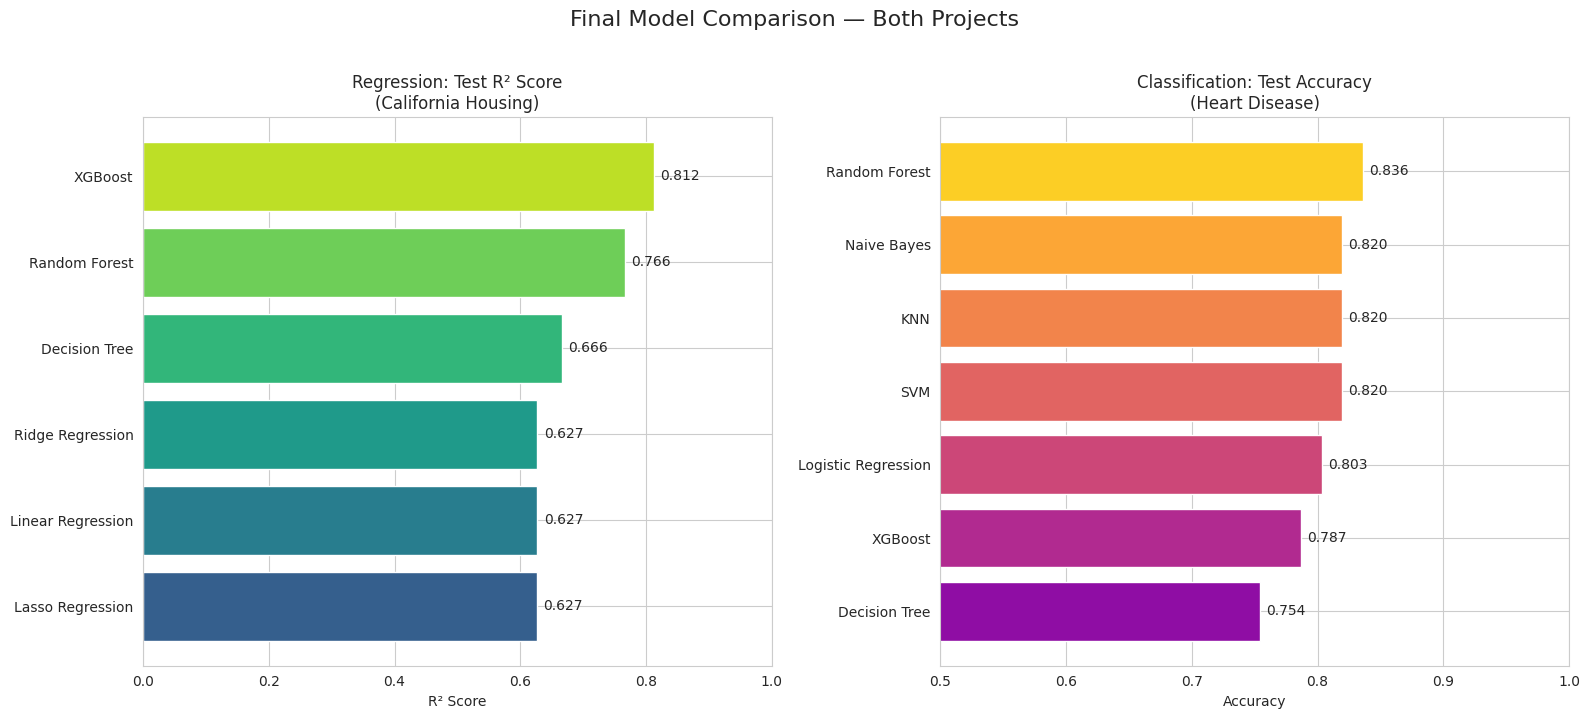

In [4]:
# side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Regression: Test R²
reg_sorted = reg_results.sort_values('Test R²', ascending=True)
colors_reg = plt.cm.viridis(np.linspace(0.3, 0.9, len(reg_sorted)))
axes[0].barh(reg_sorted.index, reg_sorted['Test R²'], color=colors_reg)
axes[0].set_xlabel('R² Score')
axes[0].set_title('Regression: Test R² Score\n(California Housing)')
axes[0].set_xlim(0, 1)
for i, v in enumerate(reg_sorted['Test R²']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

# Classification: Test Accuracy
clf_sorted = clf_results.sort_values('Test Accuracy', ascending=True)
colors_clf = plt.cm.plasma(np.linspace(0.3, 0.9, len(clf_sorted)))
axes[1].barh(clf_sorted.index, clf_sorted['Test Accuracy'], color=colors_clf)
axes[1].set_xlabel('Accuracy')
axes[1].set_title('Classification: Test Accuracy\n(Heart Disease)')
axes[1].set_xlim(0.5, 1)
for i, v in enumerate(clf_sorted['Test Accuracy']):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)

plt.suptitle('Final Model Comparison — Both Projects', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/06_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Understanding Overfitting vs Underfitting

This is one of the most important concepts in machine learning.

### What is overfitting?
The model memorizes the training data instead of learning general patterns.
It performs great on training data but poorly on new (test) data.

**Signs**: Big gap between train and test performance.

### What is underfitting?
The model is too simple to capture the patterns in the data.
It performs poorly on both training and test data.

**Signs**: Low performance on both train and test.

### The Bias-Variance Tradeoff
- **High Bias** = Underfitting (model is too simple)
- **High Variance** = Overfitting (model is too complex)
- **Sweet Spot** = Good balance between the two

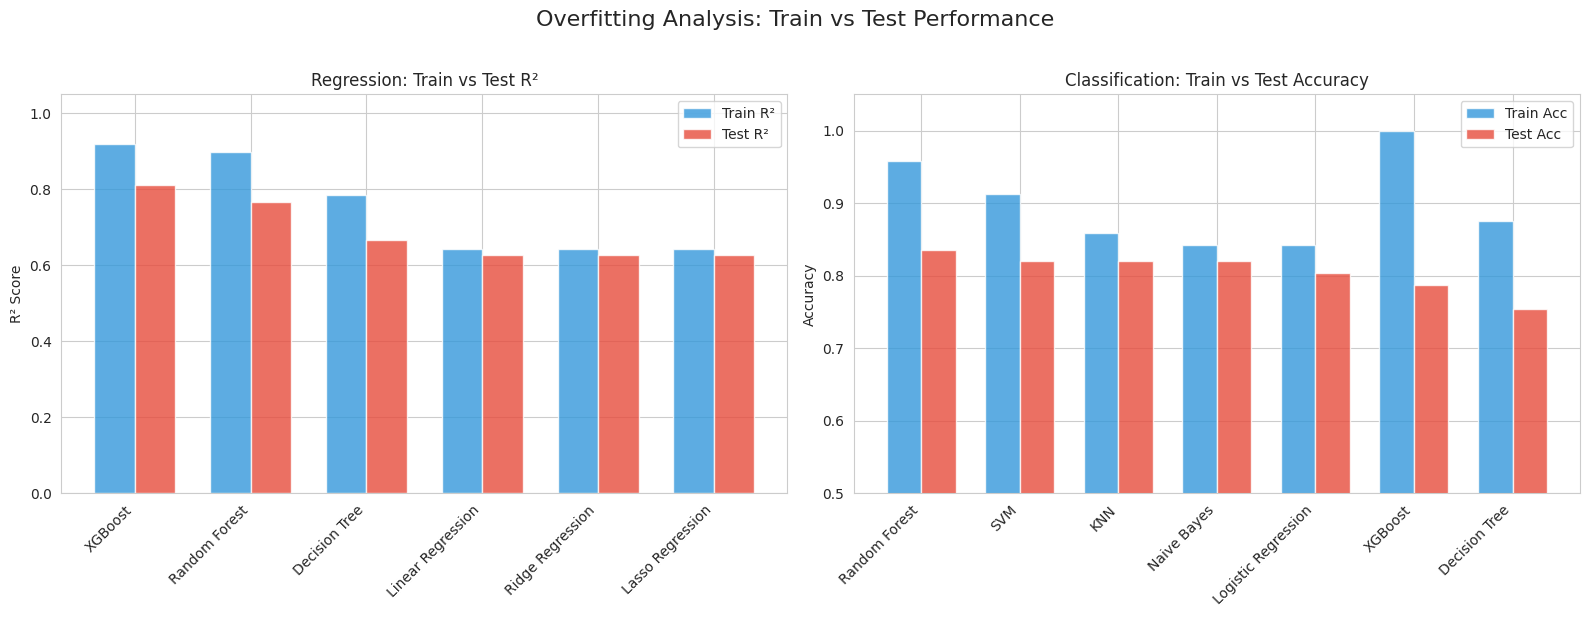

A large gap between blue and red bars = overfitting
Both bars being low = underfitting
Both bars being high and close together = good fit!


In [5]:
# visualize overfitting across all regression models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regression overfitting
x = range(len(reg_results))
width = 0.35
axes[0].bar([i - width/2 for i in x], reg_results['Train R²'], width, label='Train R²', color='#3498db', alpha=0.8)
axes[0].bar([i + width/2 for i in x], reg_results['Test R²'], width, label='Test R²', color='#e74c3c', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(reg_results.index, rotation=45, ha='right')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Regression: Train vs Test R²')
axes[0].legend()
axes[0].set_ylim(0, 1.05)

# Classification overfitting
x = range(len(clf_results))
axes[1].bar([i - width/2 for i in x], clf_results['Train Accuracy'], width, label='Train Acc', color='#3498db', alpha=0.8)
axes[1].bar([i + width/2 for i in x], clf_results['Test Accuracy'], width, label='Test Acc', color='#e74c3c', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(clf_results.index, rotation=45, ha='right')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Classification: Train vs Test Accuracy')
axes[1].legend()
axes[1].set_ylim(0.5, 1.05)

plt.suptitle('Overfitting Analysis: Train vs Test Performance', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/06_overfitting_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('A large gap between blue and red bars = overfitting')
print('Both bars being low = underfitting')
print('Both bars being high and close together = good fit!')

## 5. How We Addressed Overfitting

Throughout this project, we used several techniques to combat overfitting:

| Technique | How it helps | Where we used it |
|-----------|-------------|------------------|
| **Train-Test Split** | Evaluates on unseen data | All notebooks |
| **Cross-Validation** | More reliable performance estimate | Notebooks 3 & 5 |
| **Regularization** | Penalizes complex models (Ridge, Lasso) | Notebook 3 |
| **Tree Pruning** | Limits tree depth to prevent memorization | Notebooks 3, 4, 5 |
| **Ensemble Methods** | Combines multiple models (Random Forest) | Notebooks 3 & 5 |
| **Feature Engineering** | Creates meaningful features, removes noise | Notebook 2 |
| **Outlier Handling** | Removes extreme values that distort learning | Notebook 2 |

## 6. Model Selection Guide

Here's a practical guide for choosing the right model:

### For Regression:
- **Start with**: Linear Regression (simple baseline)
- **If underfitting**: Try Random Forest or XGBoost (captures non-linear patterns)
- **If overfitting**: Try Ridge/Lasso (adds regularization)
- **Best overall**: Random Forest or XGBoost (usually the most reliable)

### For Classification:
- **Start with**: Logistic Regression (simple, interpretable)
- **If you need interpretability**: Decision Tree
- **If you need best performance**: Random Forest or XGBoost
- **If dataset is small**: KNN or Naive Bayes
- **If you need probability estimates**: Logistic Regression or Random Forest

## 7. What We Learned (Project Summary)

### The Data Science Lifecycle in Practice:

1. **Data Loading**: Always start by understanding what you have — shape, types, missing values
2. **EDA**: Visualize everything. Distributions, correlations, outliers. Ask questions before modeling.
3. **Preprocessing**: Clean data = better models. Handle outliers, scale features, engineer new ones.
4. **Modeling**: Try multiple models. Start simple, then go complex. Always compare.
5. **Evaluation**: Use the right metrics. Cross-validate. Check for overfitting.

### Key Lessons:
- **No single model wins every time** — always try multiple approaches
- **Simple models can be surprisingly good** (Logistic Regression on heart disease)
- **Feature engineering matters** — domain knowledge improves predictions
- **Overfitting is real** — always validate on unseen data
- **Context matters** — in medical data, recall is more important than accuracy

## 8. Future Improvements

Things we could add to make this project even better:

1. **Hyperparameter Tuning**: Use GridSearchCV or RandomizedSearchCV to find optimal parameters
2. **More Feature Engineering**: Create interaction features, polynomial features
3. **Unsupervised Learning**: Add clustering (K-Means, DBSCAN) and dimensionality reduction (PCA)
4. **Deep Learning**: Try a simple neural network for comparison
5. **Model Deployment**: Build a simple web app with Streamlit or Flask
6. **More Datasets**: Add time series, NLP, or image classification projects
7. **Explainability**: Use SHAP values to explain individual predictions

---

**Thank you for following along! This project demonstrates a complete, end-to-end
machine learning workflow — from raw data to trained models and insights.**